# 📊 ANOVA (Análisis de Varianza)

## 🧠 ¿Qué es ANOVA?

ANOVA (Analysis of Variance) es una técnica estadística utilizada para comparar
las medias de **tres o más grupos independientes** y determinar si existe
una diferencia estadísticamente significativa entre ellas.

Fue desarrollada por Ronald Fisher y se basa en comparar la variabilidad
entre grupos con la variabilidad dentro de los grupos.

---

## 🎯 Objetivo de ANOVA

Determinar si las diferencias observadas entre las medias de varios grupos
son mayores a las que se esperarían por azar.

# 📊 1 - HIPOTESIS

En este notebook aplicaremos ANOVA (Análisis de Varianza)
para comparar la masa corporal promedio (body_mass_g)
entre las diferentes especies de pingüinos.

Hipótesis:

H₀: μ_Adelie = μ_Chinstrap = μ_Gentoo  
H₁: Al menos una media es diferente  

Nivel de significancia: α = 0.05

# 📌 2 – Cargar librerías y dataset

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Cargar dataset
df = sns.load_dataset("penguins")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


# 📌 3 – Limpieza de datos y muestreo

In [2]:
# Seleccionamos solo las columnas necesarias
df_clean = df[['species', 'body_mass_g']].dropna()

# Separar por especie
adelie = df_clean[df_clean['species'] == 'Adelie']['body_mass_g']
chinstrap = df_clean[df_clean['species'] == 'Chinstrap']['body_mass_g']
gentoo = df_clean[df_clean['species'] == 'Gentoo']['body_mass_g']

print("Adelie:", len(adelie))
print("Chinstrap:", len(chinstrap))
print("Gentoo:", len(gentoo))

Adelie: 151
Chinstrap: 68
Gentoo: 123


# 📌 4 – Estadísticos descriptivos

In [3]:
print("Media Adelie:", np.mean(adelie))
print("Media Chinstrap:", np.mean(chinstrap))
print("Media Gentoo:", np.mean(gentoo))

Media Adelie: 3700.662251655629
Media Chinstrap: 3733.0882352941176
Media Gentoo: 5076.016260162602


# 📌 5 – Visualización

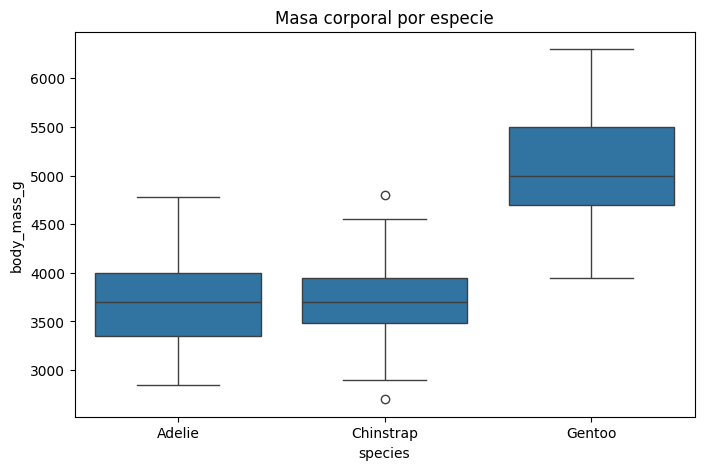

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(x='species', y='body_mass_g', data=df_clean)
plt.title("Masa corporal por especie")
plt.show()

# 📌 6 – Aplicar ANOVA

In [5]:
f_stat, p_value = stats.f_oneway(adelie, chinstrap, gentoo)

print("Estadístico F:", f_stat)
print("Valor p:", p_value)

Estadístico F: 343.626275205481
Valor p: 2.892368133377283e-82


In [6]:
print(f"Estadístico F: {f_stat:.3f}")

if p_value < 0.001:
    print("Valor p: < 0.001")
else:
    print(f"Valor p: {p_value:.4f}")

Estadístico F: 343.626
Valor p: < 0.001


## 🔎 Interpretación

Regla de decisión:

- Si p < 0.05 → Rechazamos H₀
- Si p ≥ 0.05 → No rechazamos H₀

Si el valor p es menor que 0.05, concluimos que
existe una diferencia significativa entre al menos
una de las medias de las especies.